    Date    Product  Sales  Quantity Region
0  44927  Product A    200         4  North
1  44958  Product B    150         3  South
2  44986  Product A    220         5  North
3  45017  Product C    300         6   East
4  45047  Product B    180         4   West
Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64
            Sales   Quantity
count   16.000000  16.000000
mean   237.500000   5.375000
std     64.031242   1.746425
min    150.000000   3.000000
25%    187.500000   4.000000
50%    225.000000   5.500000
75%    302.500000   7.000000
max    340.000000   8.000000
     Product  Sales  Quantity
0  Product A   1350        33
1  Product B    850        17
2  Product C   1600        36


C:\Users\nafee\AppData\Local\Temp\ipykernel_19720\2745891690.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Sales'].fillna(df['Sales'].mean(), inplace=True)


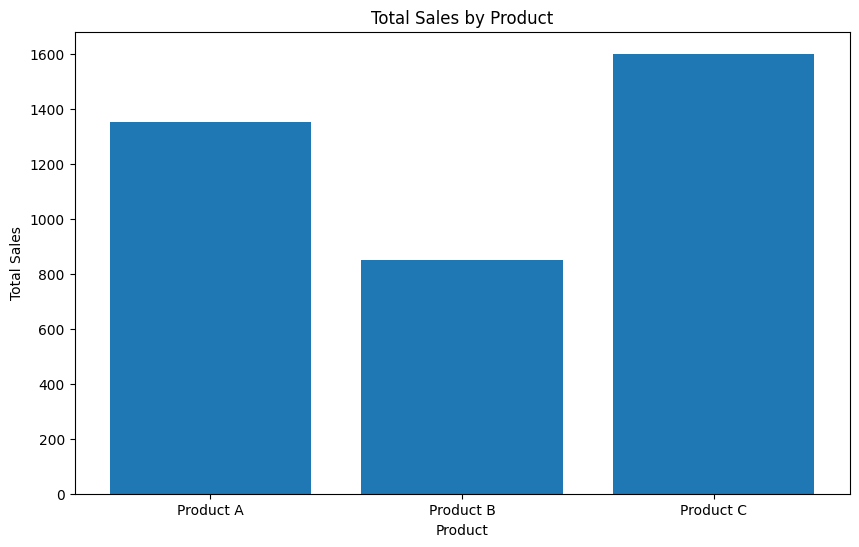

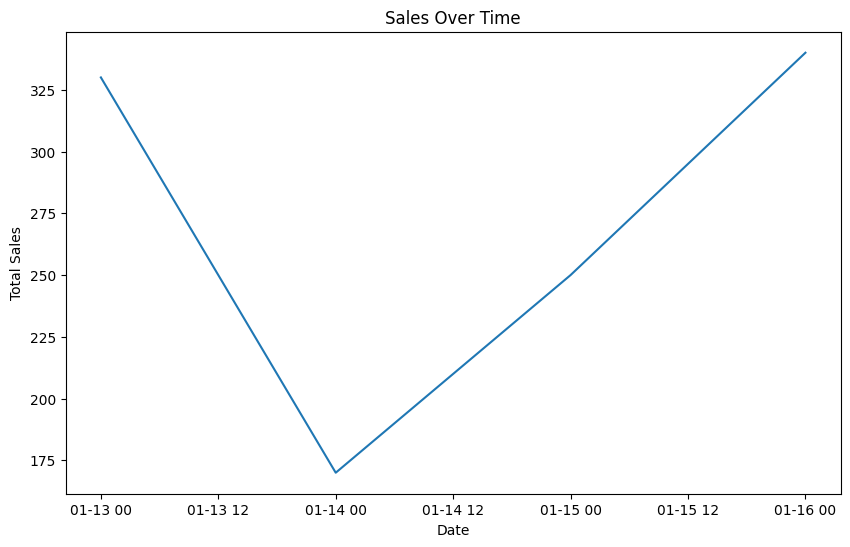

Product  Product A  Product B  Product C
Region                                  
East             0          0       1600
North         1350          0          0
South            0        480          0
West             0        370          0
             Sales  Quantity
Sales     1.000000  0.944922
Quantity  0.944922  1.000000


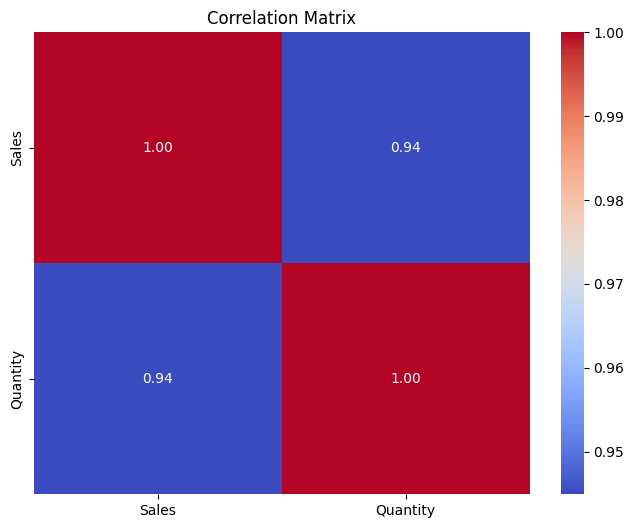

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data into a pandas DataFrame
file_path = r"C:\Users\nafee\OneDrive\Documents\sales_data.csv"
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Fill or drop missing values if necessary
df['Sales'].fillna(df['Sales'].mean(), inplace=True)
df.dropna(subset=['Product', 'Quantity', 'Region'], inplace=True)

# Summary statistics
print(df.describe())

# Group by product and calculate the total sales and quantity
product_summary = df.groupby('Product').agg({
    'Sales': 'sum',
    'Quantity': 'sum'
}).reset_index()
print(product_summary)

# Bar plot of total sales by product
plt.figure(figsize=(10, 6))
plt.bar(product_summary['Product'], product_summary['Sales'])
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product')
plt.show()

# --- FIXED DATE HANDLING ---
def convert_date(val):
    try:
        if isinstance(val, (int, float)):  # Excel serial numbers
            return pd.to_datetime('1899-12-30') + pd.to_timedelta(val, 'D')
        else:  # Strings like 13-01-2023
            return pd.to_datetime(val, dayfirst=True, errors='coerce')
    except:
        return pd.NaT

df['Date'] = df['Date'].apply(convert_date)

# Line plot of sales over time
sales_over_time = df.groupby('Date').agg({'Sales': 'sum'}).reset_index()
plt.figure(figsize=(10, 6))
plt.plot(sales_over_time['Date'], sales_over_time['Sales'])
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Over Time')
plt.show()

# Pivot table to analyze sales by region and product
pivot_table = df.pivot_table(values='Sales', index='Region', columns='Product',
                             aggfunc=np.sum, fill_value=0)
print(pivot_table)

# --- FIXED CORRELATION ---
# Only keep numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

# Heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
